# Predicting pit stop from stint number, tyre, and other data

This is my attempt at predicting whether a driver will need to make a pit stop in the next lap for the "Predicting F1 Pit Stops" playground competition on Kaggle (Yao Yan, Walter Reade, Elizabeth Park. Predicting F1 Pit Stops. https://kaggle.com/competitions/playground-series-s6e5, 2026. Kaggle.) This competition uses synthetic data inspired by the "F1 Strategy Dataset" at https://www.kaggle.com/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/data. First let's take a look at the data.

In [20]:
from setup import *
source = pd.read_csv('../data/train.csv')
source.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## First take
### Low-hanging fruit
TyreLife should be strongly correlated with the target variable. Compound may directly affect the TyreLife value at which a pit stop is warranted. Cumulative_Degradation should similarly have a strong relationship to the target. PitStop is presumably negatively correlated with PitNextLap. 
### Driver strategy
Whether to make a pit stop has much to do with the driver's strategy, and there may be traces of this in the data. For instance, if most of the drivers are going slow, a pit stop costs less. So a feature accumulating LapTimes in the same lap for different drivers might tell us something about the likelihood of a driver making a pit stop. The driver's own laptime_delta might also be somewhat indicative of favorable conditions for a pitstop.
### Environment
Important information like the temperature is missing. Perhaps this information is recoverable in Year and Race.

In [107]:
# First, let's clean it up a little so we can look at relationships.
driver_enc = OrdinalEncoder(categories='auto')
source["Driver_encoded"] = driver_enc.fit_transform(source[["Driver"]])
race_enc = OrdinalEncoder(categories='auto')
source["Race_encoded"] = race_enc.fit_transform(source[["Race"]])
compound_enc = OneHotEncoder(handle_unknown='ignore', categories='auto')
compound_cols = compound_enc.fit_transform(source[["Compound"]])
compound_cols = pd.DataFrame.sparse.from_spmatrix(compound_cols)
compound_headers = np.sort(source["Compound"].unique())

compound_cols = compound_cols.rename(columns={
    0: compound_headers[0],
    1: compound_headers[1],
    2: compound_headers[2],
    3: compound_headers[3],
    4: compound_headers[4]
})
F1_clean = pd.concat([source, compound_cols], axis=1)
F1_clean = F1_clean.drop(columns = ["Race", "Driver","Compound"])


<Axes: >

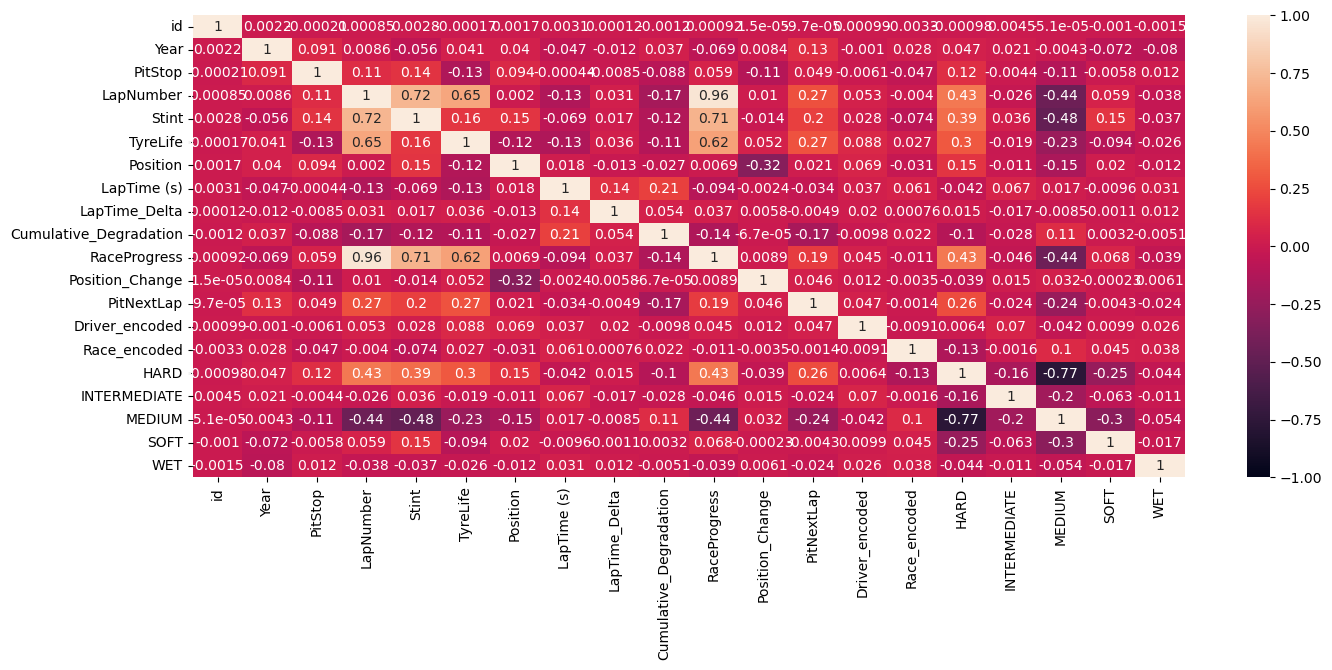

In [112]:
# Let's make a heatmap showing correlations.
plt.figure(figsize=(16, 6))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(F1_clean.corr(), vmin=-1, vmax=1, annot=True)

In [21]:
source['LapNumber'].describe()

count    439140.000000
mean         23.105909
std          16.958261
min           1.000000
25%           9.000000
50%          19.000000
75%          36.000000
max          78.000000
Name: LapNumber, dtype: float64

<Axes: >

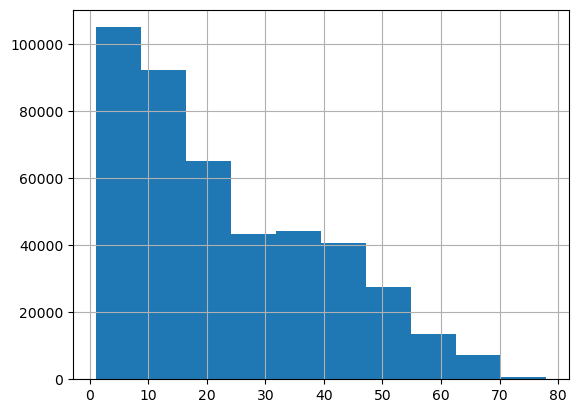

In [22]:
source['LapNumber'].hist()

<Axes: xlabel='Stint'>

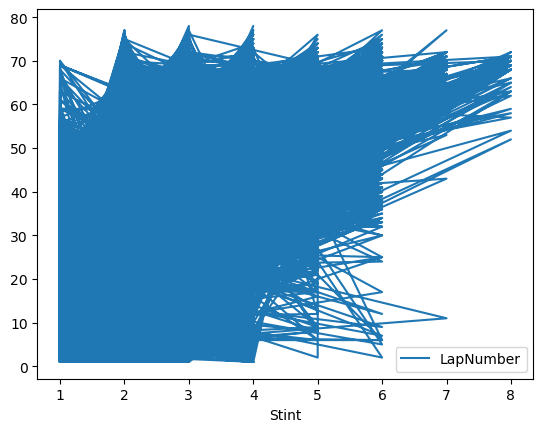

In [23]:
source.plot(kind='line', x='Stint', y='LapNumber')

This is interesting. There seems to be a correlation between stint and laps, but this tangle of lines is strange.

In [28]:
source['LapNumber'].corr(source['Stint'])

np.float64(0.7243895409301391)

There is definitely a strong correlation.

In [29]:
source[(source['Driver']=='D109') & (source['Race'] == 'Canadian Grand Prix') & (source['Year'] == 2022)]

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
55127,55127,D109,HARD,Canadian Grand Prix,2022,1,26,2,12.0,5,79.871,-31.151,158.537,0.361111,-1.0,0.0
129360,129360,D109,MEDIUM,Canadian Grand Prix,2022,0,2,1,3.0,12,80.513,-30.940,-74.804,0.027778,-4.0,1.0
173097,173097,D109,MEDIUM,Canadian Grand Prix,2022,0,15,1,15.0,4,78.086,-14.086,-21.052,0.208333,-2.0,0.0
223396,223396,D109,HARD,Canadian Grand Prix,2022,0,16,2,9.0,9,78.906,-2.828,-13.391,0.222222,-8.0,0.0
225817,225817,D109,MEDIUM,Canadian Grand Prix,2022,1,5,1,7.0,11,79.400,-31.561,-51.209,0.069444,-10.0,0.0
245616,245616,D109,MEDIUM,Canadian Grand Prix,2022,0,12,1,14.0,1,78.061,-31.107,-32.724,0.166667,2.0,0.0
293037,293037,D109,HARD,Canadian Grand Prix,2022,0,21,2,11.0,3,95.865,-42.603,31.964,0.291667,1.0,0.0
316356,316356,D109,HARD,Canadian Grand Prix,2022,0,39,2,27.0,10,79.489,-31.267,-17.895,0.541667,4.0,1.0
328772,328772,D109,HARD,Canadian Grand Prix,2022,0,34,2,20.0,11,79.829,-1.036,20.835,0.485714,0.0,0.0


In stint 1, driver D109 had Medium tires, and on stint 2, driver D109 had Hard tires. 

In [25]:
source['PitStop'].describe()

count    439140.000000
mean          0.136118
std           0.342915
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: PitStop, dtype: float64

<Axes: ylabel='Density'>

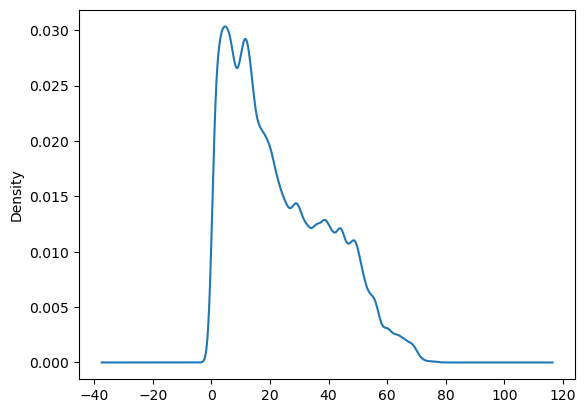

In [32]:
source['LapNumber'].plot.density()